# 2. Nettoyage et Préprocessing des Avis d'Assurance

Ce notebook nettoie et prépare les données pour les analyses suivantes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Paths
BASE_DIR = Path('..').resolve()
DATA_RAW = BASE_DIR / 'data' / 'raw'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Dépendances chargées avec succès")

Dépendances chargées avec succès


## 2.1 Chargement des données

In [2]:
import glob

# Chargement de tous les fichiers XLSX depuis le dossier du prof
XLSX_DIR = DATA_RAW / 'Traduction avis clients'
xlsx_files = sorted(glob.glob(str(XLSX_DIR / '*.xlsx')))
if not xlsx_files:
    raise FileNotFoundError(f"Aucun fichier XLSX dans {XLSX_DIR}")

print(f"Chargement de {len(xlsx_files)} fichiers XLSX...")
df_raw = pd.concat([pd.read_excel(f) for f in xlsx_files], ignore_index=True)
print(f"Dataset fusionné : {df_raw.shape}")
print(f"Colonnes : {df_raw.columns.tolist()}")
df_raw.head(3)


Chargement de 35 fichiers XLSX...
Dataset fusionné : (34435, 11)
Colonnes : ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en']


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN


In [3]:
# Mapping des colonnes réelles du dataset
# note → stars, avis_en → review (anglais, déjà traduit), assureur → insurer
col_map = {
    'note': 'stars',
    'avis_en': 'review',       # Texte anglais (déjà traduit par le prof)
    'avis': 'review_fr',       # Texte français original (conservé)
    'assureur': 'insurer',
    'date_publication': 'date',
    'produit': 'product',
}
# Appliquer uniquement les colonnes qui existent
col_map_filtered = {k: v for k, v in col_map.items() if k in df_raw.columns}
df = df_raw.rename(columns=col_map_filtered)

print(f"Colonnes après mapping : {df.columns.tolist()}")
print(f"Shape : {df.shape}")

# Forcer le type numérique pour stars
df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
print(f"\nDistribution des étoiles :\n{df['stars'].value_counts().sort_index()}")
df.head(3)


Colonnes après mapping : ['stars', 'auteur', 'review_fr', 'insurer', 'product', 'type', 'date', 'date_exp', 'review', 'avis_cor', 'avis_cor_en']
Shape : (34435, 11)

Distribution des étoiles :
stars
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64


,stars,auteur,review_fr,insurer,product,type,date,date_exp,review,avis_cor,avis_cor_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN


## 2.2 Suppression des doublons et valeurs manquantes

In [4]:
print("=== Analyse avant nettoyage ===")
print(f"Lignes totales : {len(df)}")
print(f"Doublons : {df.duplicated().sum()}")
print(f"\nValeurs manquantes :")
print(df.isnull().sum())

# Suppression des doublons
df = df.drop_duplicates()
print(f"\nAprès suppression doublons : {len(df)} lignes")

# Suppression des reviews vides
if 'review' in df.columns:
    before = len(df)
    df = df.dropna(subset=['review'])
    df = df[df['review'].str.strip().str.len() > 10]
    print(f"Après suppression reviews vides : {len(df)} lignes (supprimé {before - len(df)})")

# Nettoyage étoiles
if 'stars' in df.columns:
    df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
    df = df.dropna(subset=['stars'])
    df['stars'] = df['stars'].clip(1, 5).astype(int)
    print(f"\nDistribution étoiles après nettoyage :")
    print(df['stars'].value_counts().sort_index())

=== Analyse avant nettoyage ===
Lignes totales : 34435
Doublons : 5

Valeurs manquantes :
stars          10331
auteur             1
review_fr          0
insurer            0
product            0
type               0
date               0
date_exp           0
review             2
avis_cor       34000
avis_cor_en    34004
dtype: int64

Après suppression doublons : 34430 lignes
Après suppression reviews vides : 33277 lignes (supprimé 1153)

Distribution étoiles après nettoyage :
stars
1    7086
2    3632
3    3289
4    4768
5    4741
Name: count, dtype: int64


## 2.3 Normalisation du texte

In [5]:
def normalize_text(text):
    """Normalisation de base : lowercase, ponctuation, espaces."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Supprimer URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Supprimer emails
    text = re.sub(r'\S+@\S+', '', text)
    # Supprimer chiffres isolés
    text = re.sub(r'\b\d+\b', '', text)
    # Supprimer ponctuation sauf apostrophe
    text = re.sub(r"[^a-z\s']", ' ', text)
    # Normaliser apostrophes
    text = re.sub(r"'s\b", '', text)
    # Supprimer espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
sample = "I've been with State Farm for 5 years! Great service & fast claims. Visit https://example.com"
print("Original :", sample)
print("Normalisé :", normalize_text(sample))

Original : I've been with State Farm for 5 years! Great service & fast claims. Visit https://example.com
Normalisé : i've been with state farm for years great service fast claims visit


## 2.4 Suppression des stopwords

In [6]:
STOPWORDS_EN = set(stopwords.words('english'))
# Garder quelques mots de négation importants pour le sentiment
KEEP_WORDS = {'no', 'not', 'never', 'nothing', 'nobody', 'neither', "n't", 'without', 'against'}
STOPWORDS_EN = STOPWORDS_EN - KEEP_WORDS

def remove_stopwords(text):
    """Supprime les stopwords."""
    tokens = text.split()
    return ' '.join([w for w in tokens if w not in STOPWORDS_EN])

# Test
sample_clean = normalize_text(sample)
print("Avec stopwords    :", sample_clean)
print("Sans stopwords    :", remove_stopwords(sample_clean))

Avec stopwords    : i've been with state farm for years great service fast claims visit
Sans stopwords    : state farm years great service fast claims visit


## 2.5 Correction orthographique (optionnel)

In [7]:
try:
    from spellchecker import SpellChecker
    spell = SpellChecker()
    
    def correct_spelling(text, max_words=50):
        """Correction orthographique (appliquée aux N premiers mots pour la vitesse)."""
        words = text.split()[:max_words]
        corrected = []
        for word in words:
            if len(word) > 2 and word.isalpha():
                corrected.append(spell.correction(word) or word)
            else:
                corrected.append(word)
        return ' '.join(corrected)
    
    # Test sur un exemple
    test_txt = "the insuranc compny was helpfull with my cliam"
    print("Original  :", test_txt)
    print("Corrigé   :", correct_spelling(test_txt))
    SPELL_AVAILABLE = True
    
except ImportError:
    print("pyspellchecker non disponible. Installer avec : pip install pyspellchecker")
    SPELL_AVAILABLE = False
    def correct_spelling(text, max_words=50):
        return text

pyspellchecker non disponible. Installer avec : pip install pyspellchecker


## 2.6 Détection et traduction des langues

In [8]:
# Note : les reviews sont déjà traduites en anglais dans la colonne 'avis_en' (→ 'review')
# La détection de langue est donc optionnelle/informative uniquement

print("ℹ️  Le dataset contient déjà les traductions anglaises (colonne avis_en).")
print("   Pas besoin de traduction supplémentaire.")
print(f"   Reviews en anglais disponibles : {df['review'].notna().sum()} / {len(df)}")

LANG_AVAILABLE = False  # Désactivé car déjà traduit
def detect_language(text):
    return 'en'


ℹ️  Le dataset contient déjà les traductions anglaises (colonne avis_en).
   Pas besoin de traduction supplémentaire.
   Reviews en anglais disponibles : 23516 / 23516


In [9]:
# Traduction déjà effectuée par le prof (colonne avis_en)
# On conserve aussi le texte français dans review_fr pour référence

print("ℹ️  Traduction déjà disponible dans le dataset.")
print(f"   Exemples de paires FR → EN :")
for _, row in df[['review_fr', 'review']].dropna().head(2).iterrows():
    print(f"\n  FR: {str(row.get('review_fr', ''))[:100]}")
    print(f"  EN: {str(row.get('review', ''))[:100]}")

TRANSLATE_AVAILABLE = True  # Données déjà en anglais
def translate_to_english(text, source_lang='auto'):
    return text  # Déjà traduit


ℹ️  Traduction déjà disponible dans le dataset.
   Exemples de paires FR → EN :

  FR: La personne au téléphone était Clair et sympathique elle m'a bien tout expliqué je recommanderai vot
  EN: The person on the phone was clear and friendly she explained everything to me I would recommend your

  FR: Satisfait.

Réactivité, simplicité. Prix attractif d’un point de vue concurrence. A voir la réactivi
  EN: Satisfied.

Reactivity, simplicity. Attractive price from a competition point of view. To see the re


## 2.7 Lemmatisation avec spaCy

In [10]:
try:
    import spacy
    
    try:
        nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    except OSError:
        print("Modèle spaCy non trouvé. Téléchargement...")
        os.system('python -m spacy download en_core_web_sm')
        nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    
    def lemmatize_text(text):
        """Lemmatise le texte avec spaCy."""
        doc = nlp(str(text)[:500])  # Limiter la longueur
        return ' '.join([token.lemma_ for token in doc 
                        if not token.is_stop and not token.is_punct and len(token.text) > 2])
    
    # Test
    test_sentence = "the company denied my claims and cancelled my insurance policy"
    print("Original  :", test_sentence)
    print("Lemmatisé :", lemmatize_text(test_sentence))
    SPACY_AVAILABLE = True
    
except ImportError:
    print("spaCy non disponible. Utilisation du split simple.")
    SPACY_AVAILABLE = False
    def lemmatize_text(text):
        return remove_stopwords(text)

spaCy non disponible. Utilisation du split simple.


## 2.8 Pipeline de preprocessing complet

In [11]:
def preprocess_pipeline(text):
    """Pipeline complet de préprocessing."""
    if pd.isna(text) or str(text).strip() == '':
        return ''
    
    # Étape 1 : Normalisation
    text = normalize_text(text)
    
    # Étape 2 : Correction orthographique (désactivée par défaut - trop lente)
    # text = correct_spelling(text)
    
    # Étape 3 : Lemmatisation
    if SPACY_AVAILABLE:
        text = lemmatize_text(text)
    else:
        text = remove_stopwords(text)
    
    return text

# Test du pipeline complet
test_reviews = [
    "I've had a terrible experience with this insurance company! They denied my claim for no reason.",
    "Great coverage and affordable prices. Customer service was very helpful.",
    "Cancelled my policy after 3 months. The premium increased without notice."
]

print("=== Test du pipeline ===")
for review in test_reviews:
    cleaned = preprocess_pipeline(review)
    print(f"\nOriginal : {review[:80]}")
    print(f"Nettoyé  : {cleaned[:80]}")

=== Test du pipeline ===

Original : I've had a terrible experience with this insurance company! They denied my claim
Nettoyé  : terrible experience insurance company denied claim no reason

Original : Great coverage and affordable prices. Customer service was very helpful.
Nettoyé  : great coverage affordable prices customer service helpful

Original : Cancelled my policy after 3 months. The premium increased without notice.
Nettoyé  : cancelled policy months premium increased without notice


In [12]:
try:
    from tqdm.auto import tqdm
    tqdm.pandas()
    USE_TQDM = True
except ImportError:
    USE_TQDM = False

print("Application du pipeline de preprocessing sur 'review' (anglais)...")

if USE_TQDM:
    df['review_clean'] = df['review'].progress_apply(preprocess_pipeline)
else:
    df['review_clean'] = df['review'].apply(preprocess_pipeline)

# Métriques
df['review_length'] = df['review'].str.len()
df['review_clean_length'] = df['review_clean'].str.len()
df['word_count'] = df['review_clean'].str.split().str.len()
df['language'] = 'en'  # Toutes les reviews sont en anglais (déjà traduites)

print(f"\n✅ Preprocessing terminé : {len(df)} reviews")
print(f"Longueur moyenne originale (EN) : {df['review_length'].mean():.0f} car.")
print(f"Longueur moyenne nettoyée       : {df['review_clean_length'].mean():.0f} car.")
print(f"Mots moyens (nettoyé)           : {df['word_count'].mean():.1f}")


Application du pipeline de preprocessing sur 'review' (anglais)...


  0%|          | 0/23516 [00:00<?, ?it/s]


✅ Preprocessing terminé : 23516 reviews
Longueur moyenne originale (EN) : 321 car.
Longueur moyenne nettoyée       : 203 car.
Mots moyens (nettoyé)           : 27.8


## 2.9 Analyse post-nettoyage

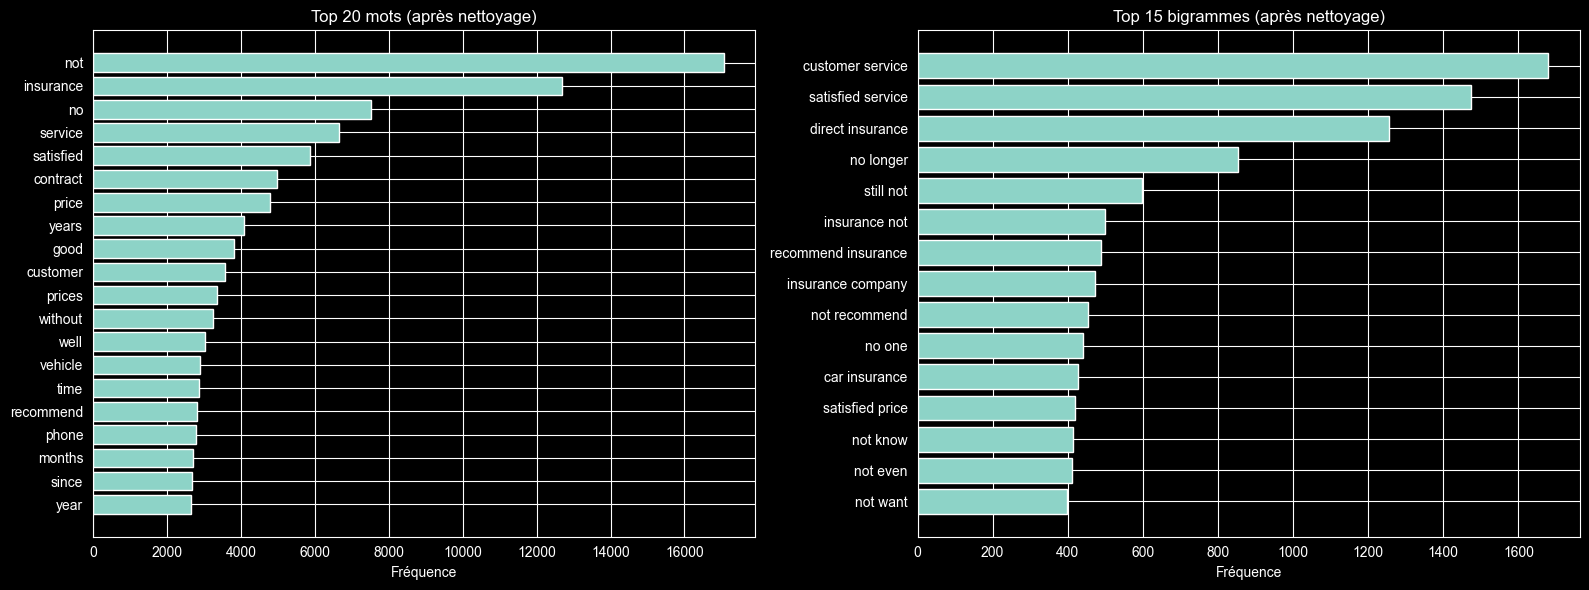

Graphique sauvegardé


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top mots unigrams
vectorizer_uni = CountVectorizer(max_features=30, ngram_range=(1,1))
X_uni = vectorizer_uni.fit_transform(df['review_clean'].fillna(''))
word_freq = pd.DataFrame({
    'word': vectorizer_uni.get_feature_names_out(),
    'count': X_uni.toarray().sum(axis=0)
}).sort_values('count', ascending=True)

axes[0].barh(word_freq['word'].tail(20), word_freq['count'].tail(20))
axes[0].set_title('Top 20 mots (après nettoyage)')
axes[0].set_xlabel('Fréquence')

# Bigrammes
vectorizer_bi = CountVectorizer(max_features=20, ngram_range=(2,2))
X_bi = vectorizer_bi.fit_transform(df['review_clean'].fillna(''))
bigram_freq = pd.DataFrame({
    'bigram': vectorizer_bi.get_feature_names_out(),
    'count': X_bi.toarray().sum(axis=0)
}).sort_values('count', ascending=True)

axes[1].barh(bigram_freq['bigram'].tail(15), bigram_freq['count'].tail(15))
axes[1].set_title('Top 15 bigrammes (après nettoyage)')
axes[1].set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig('../data/processed/word_frequencies.png', dpi=100, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé")

## 2.10 Export des données nettoyées

In [14]:
# Colonnes essentielles à conserver
base_cols = ['review', 'review_clean', 'review_length', 'word_count', 'language']
optional_cols = ['stars', 'insurer', 'date', 'product', 'review_fr']
cols_to_save = [c for c in optional_cols + base_cols if c in df.columns]

df_clean = df[cols_to_save].copy()

# Supprimer les lignes sans review_clean
df_clean = df_clean[df_clean['review_clean'].str.strip().str.len() > 0]

output_path = DATA_PROCESSED / 'reviews_clean.csv'
df_clean.to_csv(output_path, index=False)

print(f"✅ Dataset nettoyé sauvegardé :")
print(f"   Fichier  : {output_path}")
print(f"   Shape    : {df_clean.shape}")
print(f"   Colonnes : {df_clean.columns.tolist()}")
df_clean.head(3)


✅ Dataset nettoyé sauvegardé :
   Fichier  : /Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/data/processed/reviews_clean.csv
   Shape    : (23516, 10)
   Colonnes : ['stars', 'insurer', 'date', 'product', 'review_fr', 'review', 'review_clean', 'review_length', 'word_count', 'language']


,stars,insurer,date,product,review_fr,review,review_clean,review_length,word_count,language
0,4,L'olivier Assurance,06/10/2021,auto,La personne au téléphone était Clair et sympat...,The person on the phone was clear and friendly...,person phone clear friendly explained everythi...,165,14,en
1,4,APRIL Moto,09/07/2021,moto,"Satisfait.\n\nRéactivité, simplicité. Prix att...","Satisfied.\n\nReactivity, simplicity. Attracti...",satisfied reactivity simplicity attractive pri...,176,14,en
2,1,SwissLife,15/10/2020,vie,"Assureur à fuir, n assure pas ses responsabili...","Insurer to flee, does not ensure its responsib...",insurer flee not ensure responsibilities insur...,203,21,en
